In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, GRU, Dense, Dropout, SimpleRNN
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [22]:
data = pd.read_csv('Tweets.csv')
data.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [23]:
# clean text + encode labels
texts = data['text'].fillna('').astype(str).values
labels = LabelEncoder().fit_transform(data['sentiment'])

# split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# BERT tokenize
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_len = 50

X_train = tokenizer(
    list(X_train_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

X_test = tokenizer(
    list(X_test_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

In [ ]:
%%time
vocab_size = int(max(X_train.max(), X_test.max())) + 1

def build_rnn():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=50),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=50),
        LSTM(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_gru():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=50),
        GRU(128),
        Dense(3, activation='softmax')
    ])
    return model

CPU times: total: 0 ns
Wall time: 1.37 ms


In [27]:
models = {
    'RNN': build_rnn(),
    'LSTM': build_lstm(),
    'GRU': build_gru()
}

results = {}

for name, model in models.items():
    print(f'Training {name} model...')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    start = time.time()
    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping]
    )

    end = time.time()
    results[name] = {
        'history': history,
        'training_time': end - start
    }

Training RNN model...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4016 - loss: 1.0885 - val_accuracy: 0.4499 - val_loss: 1.0894
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.4563 - loss: 1.0395 - val_accuracy: 0.4826 - val_loss: 0.9970
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4724 - loss: 1.0127 - val_accuracy: 0.4153 - val_loss: 1.0551
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4440 - loss: 1.0410 - val_accuracy: 0.3838 - val_loss: 1.0819
Training LSTM model...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.4038 - loss: 1.0882 - val_accuracy: 0.4160 - val_loss: 1.0658
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4362 - loss: 1.0500 - val_accuracy: 0.4948 - val_loss: 0.9782
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.6532 - loss: 0.7760 - val_accuracy: 0.7197 - val_loss: 0.6699
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 3

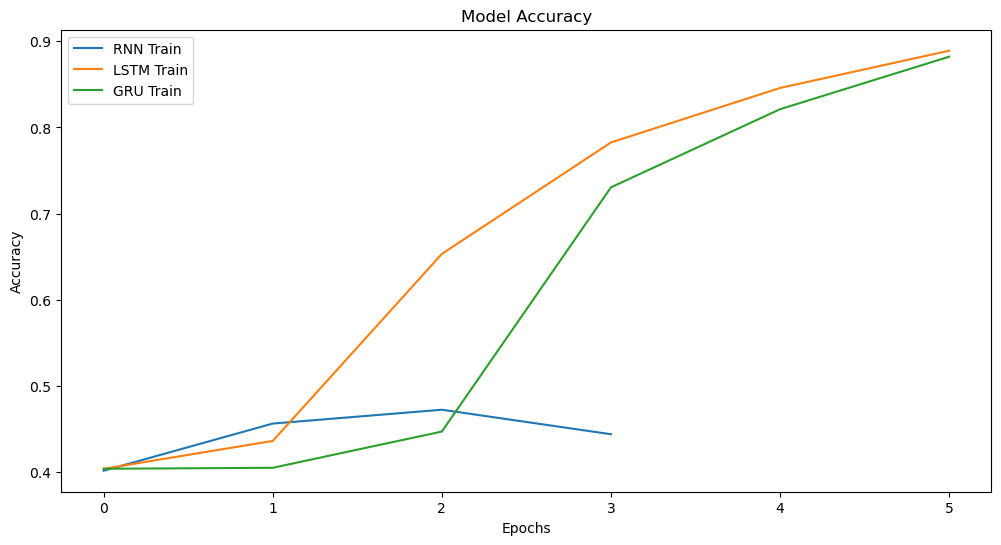

In [31]:
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result['history'].history['accuracy'], label=f'{name} Train')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

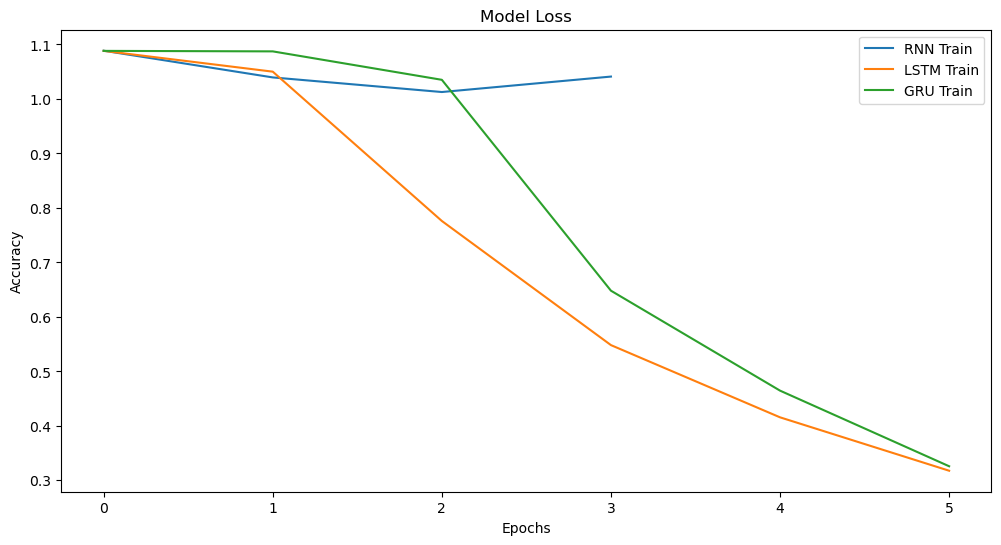

In [32]:
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result['history'].history['loss'], label=f'{name} Train')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [34]:
Sequence = [10, 20, 40, 60, 80]
rnn_acc, lstm_acc, gru_acc = [], [], []

for l in Sequence:
    print(f'Testing sequence length: {l}')

    X_train_l = tokenizer(
        list(X_train_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    X_test_l = tokenizer(
        list(X_test_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    vocab_size_l = int(max(X_train_l.max(), X_test_l.max())) + 1

    rnn_model = Sequential([
        Embedding(vocab_size_l, 128),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])
    lstm_model = Sequential([
        Embedding(vocab_size_l, 128),
        LSTM(128),
        Dense(3, activation='softmax')
    ])
    gru_model = Sequential([
        Embedding(vocab_size_l, 128),
        GRU(128),
        Dense(3, activation='softmax')
    ])

    model_map = {
        'RNN': rnn_model,
        'LSTM': lstm_model,
        'GRU': gru_model
    }

    for model_name, model_obj in model_map.items():
        model_obj.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        es = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
        model_obj.fit(
            X_train_l,
            y_train,
            epochs=3,
            batch_size=64,
            validation_data=(X_test_l, y_test),
            callbacks=[es],
            verbose=0
        )
        _, test_acc = model_obj.evaluate(X_test_l, y_test, verbose=0)

        if model_name == 'RNN':
            rnn_acc.append(test_acc)
        elif model_name == 'LSTM':
            lstm_acc.append(test_acc)
        else:
            gru_acc.append(test_acc)

print('RNN accuracies:', rnn_acc)
print('LSTM accuracies:', lstm_acc)
print('GRU accuracies:', gru_acc)

Testing sequence length: 10
Testing sequence length: 20
Testing sequence length: 40
Testing sequence length: 60
Testing sequence length: 80
RNN accuracies: [0.5930507779121399, 0.5897762179374695, 0.6579952836036682, 0.5404766201972961, 0.4045843183994293]
LSTM accuracies: [0.5952337384223938, 0.6750954985618591, 0.707476794719696, 0.4857194721698761, 0.4045843183994293]
GRU accuracies: [0.5952337384223938, 0.6845552325248718, 0.7253047227859497, 0.4045843183994293, 0.4045843183994293]
